# Retinal Vessel Segmentation - DRIVE + STARE

Single Colab notebook for training a compact U-Net on DRIVE patches and checking transfer performance on STARE.

Expected data layout after upload/extract:
```
archive/DRIVE/training/images
archive/DRIVE/training/1st_manual
archive/DRIVE/training/mask
archive/DRIVE/test/images
archive/DRIVE/test/1st_manual
archive/DRIVE/test/mask
archive/STARE/stare-images
archive/STARE/labels-ah
archive/STARE/labels-vk
```


## 1. Setup
Upload `archive.zip` to Colab or mount Google Drive and set `DATA_ROOT` to the extracted `archive` folder.


In [1]:
from google.colab import drive
drive.mount('/content/drive')

!cp "/content/drive/MyDrive/archive.zip" /content/archive.zip
!unzip -oq /content/archive.zip -d /content



DATA_ROOT = '/content/archive'  # change if needed


Mounted at /content/drive


In [2]:
import os, gzip, io, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Data Checks


In [3]:
root = Path(DATA_ROOT)
folders = [
    'DRIVE/training/images', 'DRIVE/training/1st_manual', 'DRIVE/training/mask',
    'DRIVE/test/images', 'DRIVE/test/1st_manual', 'DRIVE/test/mask',
    'STARE/stare-images', 'STARE/labels-ah', 'STARE/labels-vk'
]
for folder in folders:
    files = sorted([p for p in (root / folder).glob('*') if p.is_file() and not p.name.startswith('.')])
    print(f'{folder:30s} {len(files):2d} files')
    assert len(files) > 0, f'Missing files in {folder}'


DRIVE/training/images          20 files
DRIVE/training/1st_manual      20 files
DRIVE/training/mask            20 files
DRIVE/test/images              20 files
DRIVE/test/1st_manual          20 files
DRIVE/test/mask                20 files
STARE/stare-images             20 files
STARE/labels-ah                20 files
STARE/labels-vk                20 files


In [4]:
def open_image(path):
    path = Path(path)
    if path.suffix == '.gz':
        with gzip.open(path, 'rb') as f:
            return Image.open(io.BytesIO(f.read())).copy()
    return Image.open(path).copy()

def load_rgb(path):
    return np.asarray(open_image(path).convert('RGB'), dtype=np.float32) / 255.0

def load_mask(path):
    arr = np.asarray(open_image(path).convert('L'), dtype=np.float32)
    return (arr > 127).astype(np.float32)[..., None]

def drive_paths(split):
    image_dir = root / 'DRIVE' / split / 'images'
    label_dir = root / 'DRIVE' / split / '1st_manual'
    fov_dir = root / 'DRIVE' / split / 'mask'
    rows = []
    for img in sorted(image_dir.glob('*.tif')):
        idx = img.name.split('_')[0]
        label = label_dir / f'{idx}_manual1.gif'
        fov = fov_dir / f'{idx}_{split}_mask.gif'
        rows.append((img, label, fov))
    return rows

train_rows = drive_paths('training')
test_rows = drive_paths('test')
print('DRIVE train/test:', len(train_rows), len(test_rows))
print('Sample shape:', load_rgb(train_rows[0][0]).shape, load_mask(train_rows[0][1]).shape)


DRIVE train/test: 20 20
Sample shape: (584, 565, 3) (584, 565, 1)


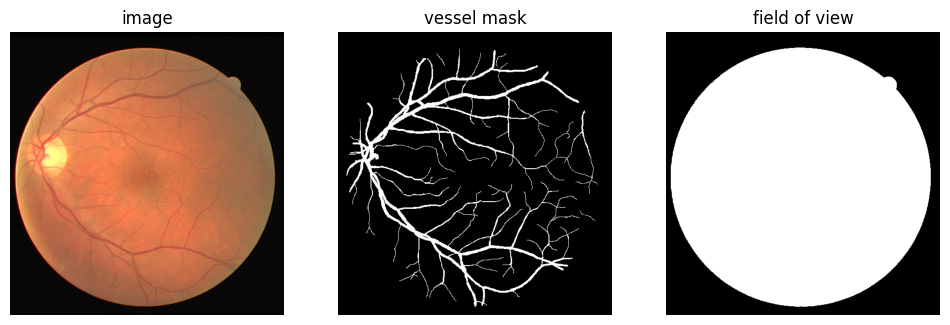

In [5]:
img = load_rgb(train_rows[0][0]); y = load_mask(train_rows[0][1]); fov = load_mask(train_rows[0][2])
plt.figure(figsize=(12,4))
for i, (title, arr) in enumerate([('image', img), ('vessel mask', y[...,0]), ('field of view', fov[...,0])]):
    plt.subplot(1,3,i+1); plt.imshow(arr, cmap='gray'); plt.title(title); plt.axis('off')
plt.show()


## 3. Patch Extraction
Training uses random patches sampled mostly inside the field-of-view mask.


## 3. Experiment Configuration

We will run three controlled experiments:

| Experiment | Input | Model |
|---|---|---|
| E1 | RGB | U-Net |
| E2 | Green channel | U-Net |
| E3 | Green channel + CLAHE | U-Net |

For a faster first run, keep `PATCHES_PER_IMAGE` and `EPOCHS` modest. For final report numbers, increase them and rerun all experiments under the same settings.


In [ ]:
PATCH_SIZE = 128
PATCHES_PER_IMAGE = 250
BATCH_SIZE = 16
EPOCHS = 20

EXPERIMENTS = [
    {'name': 'E1_RGB_UNet', 'preprocess': 'rgb', 'input_channels': 3},
    {'name': 'E2_Green_UNet', 'preprocess': 'green', 'input_channels': 1},
    {'name': 'E3_Green_CLAHE_UNet', 'preprocess': 'green_clahe', 'input_channels': 1},
]


## 4. Preprocessing and Patch Extraction


In [7]:
def preprocess_image(image_rgb, mode):
    if mode == 'rgb':
        return image_rgb.astype(np.float32)

    green = image_rgb[:, :, 1]
    if mode == 'green':
        return green[..., None].astype(np.float32)

    if mode == 'green_clahe':
        green_u8 = np.clip(green * 255.0, 0, 255).astype(np.uint8)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
        enhanced = clahe.apply(green_u8).astype(np.float32) / 255.0
        return enhanced[..., None]

    raise ValueError(f'Unknown preprocessing mode: {mode}')


def extract_patches(rows, preprocess_mode, patch_size=128, patches_per_image=250):
    xs, ys = [], []
    half = patch_size // 2
    for image_path, label_path, fov_path in rows:
        image = preprocess_image(load_rgb(image_path), preprocess_mode)
        label = load_mask(label_path)
        fov = load_mask(fov_path)[..., 0]
        h, w = fov.shape
        valid = np.argwhere(fov > 0)
        for _ in range(patches_per_image):
            cy, cx = valid[np.random.randint(len(valid))]
            y0 = int(np.clip(cy - half, 0, h - patch_size))
            x0 = int(np.clip(cx - half, 0, w - patch_size))
            xs.append(image[y0:y0+patch_size, x0:x0+patch_size])
            ys.append(label[y0:y0+patch_size, x0:x0+patch_size])
    return np.asarray(xs, dtype=np.float32), np.asarray(ys, dtype=np.float32)


def make_datasets(X, Y, batch_size=16, val_fraction=0.15):
    perm = np.random.permutation(len(X))
    split = int((1.0 - val_fraction) * len(X))
    train_idx, val_idx = perm[:split], perm[split:]

    def augment(x, y):
        if tf.random.uniform(()) > 0.5:
            x = tf.image.flip_left_right(x); y = tf.image.flip_left_right(y)
        if tf.random.uniform(()) > 0.5:
            x = tf.image.flip_up_down(x); y = tf.image.flip_up_down(y)
        k = tf.random.uniform((), minval=0, maxval=4, dtype=tf.int32)
        return tf.image.rot90(x, k), tf.image.rot90(y, k)

    train_ds = (tf.data.Dataset.from_tensor_slices((X[train_idx], Y[train_idx]))
                .shuffle(2048).map(augment, num_parallel_calls=tf.data.AUTOTUNE)
                .batch(batch_size).prefetch(tf.data.AUTOTUNE))
    val_ds = (tf.data.Dataset.from_tensor_slices((X[val_idx], Y[val_idx]))
              .batch(batch_size).prefetch(tf.data.AUTOTUNE))
    return train_ds, val_ds


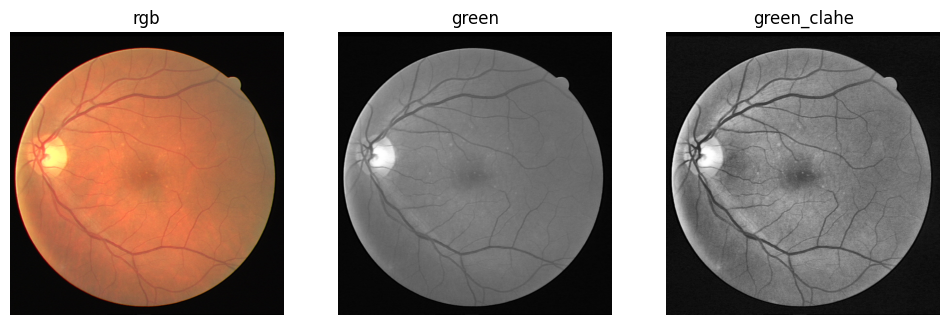

In [8]:
# Quick visual check for the three input types.
sample_rgb = load_rgb(train_rows[0][0])
plt.figure(figsize=(12, 4))
for i, mode in enumerate(['rgb', 'green', 'green_clahe']):
    arr = preprocess_image(sample_rgb, mode)
    plt.subplot(1, 3, i + 1)
    plt.imshow(arr if arr.shape[-1] == 3 else arr[..., 0], cmap=None if arr.shape[-1] == 3 else 'gray')
    plt.title(mode)
    plt.axis('off')
plt.show()


## 5. U-Net Model


In [ ]:
def conv_block(x, filters):
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(filters, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    return x


def build_unet(input_shape=(128, 128, 3), base=32):
    inputs = keras.Input(input_shape)
    c1 = conv_block(inputs, base); p1 = layers.MaxPool2D()(c1)
    c2 = conv_block(p1, base * 2); p2 = layers.MaxPool2D()(c2)
    c3 = conv_block(p2, base * 4); p3 = layers.MaxPool2D()(c3)
    c4 = conv_block(p3, base * 8)
    u3 = layers.UpSampling2D()(c4); u3 = layers.Concatenate()([u3, c3]); c5 = conv_block(u3, base * 4)
    u2 = layers.UpSampling2D()(c5); u2 = layers.Concatenate()([u2, c2]); c6 = conv_block(u2, base * 2)
    u1 = layers.UpSampling2D()(c6); u1 = layers.Concatenate()([u1, c1]); c7 = conv_block(u1, base)
    outputs = layers.Conv2D(1, 1, activation='sigmoid')(c7)
    return keras.Model(inputs, outputs)


def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred > 0.5, tf.float32)
    inter = tf.reduce_sum(y_true * y_pred)
    return (2.0 * inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


def dice_loss(y_true, y_pred, smooth=1e-6):
    inter = tf.reduce_sum(y_true * y_pred)
    return 1.0 - (2.0 * inter + smooth) / (tf.reduce_sum(y_true) + tf.reduce_sum(y_pred) + smooth)


def bce_dice_loss(y_true, y_pred):
    return keras.losses.binary_crossentropy(y_true, y_pred) + dice_loss(y_true, y_pred)


## 6. Full-Image Inference and Metrics


In [ ]:
def predict_full_image(model, image, preprocess_mode, patch_size=128, stride=64):
    image = preprocess_image(image, preprocess_mode)
    h, w, c = image.shape
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    padded = np.pad(image, ((0, pad_h), (0, pad_w), (0, 0)), mode='reflect')
    ph, pw, _ = padded.shape
    prob = np.zeros((ph, pw, 1), dtype=np.float32)
    count = np.zeros((ph, pw, 1), dtype=np.float32)

    y_positions = list(range(0, ph - patch_size + 1, stride))
    x_positions = list(range(0, pw - patch_size + 1, stride))
    if y_positions[-1] != ph - patch_size:
        y_positions.append(ph - patch_size)
    if x_positions[-1] != pw - patch_size:
        x_positions.append(pw - patch_size)

    for y0 in y_positions:
        for x0 in x_positions:
            patch = padded[y0:y0+patch_size, x0:x0+patch_size][None]
            pred = model.predict(patch, verbose=0)[0]
            prob[y0:y0+patch_size, x0:x0+patch_size] += pred
            count[y0:y0+patch_size, x0:x0+patch_size] += 1
    return (prob / np.maximum(count, 1))[:h, :w]


def binary_metrics(y_true, y_prob, fov=None, threshold=0.5):
    yt = y_true[..., 0].astype(bool)
    yp = y_prob[..., 0] >= threshold
    valid = np.ones_like(yt, dtype=bool) if fov is None else fov[..., 0].astype(bool)
    yt, yp = yt[valid], yp[valid]
    tp = np.logical_and(yt, yp).sum(); tn = np.logical_and(~yt, ~yp).sum()
    fp = np.logical_and(~yt, yp).sum(); fn = np.logical_and(yt, ~yp).sum()
    return {
        'accuracy': (tp + tn) / max(tp + tn + fp + fn, 1),
        'dice': (2 * tp) / max(2 * tp + fp + fn, 1),
        'sensitivity': tp / max(tp + fn, 1),
        'specificity': tn / max(tn + fp, 1),
    }


def evaluate_drive(model, preprocess_mode):
    rows = []
    for image_path, label_path, fov_path in test_rows:
        image = load_rgb(image_path); label = load_mask(label_path); fov = load_mask(fov_path)
        prob = predict_full_image(model, image, preprocess_mode, PATCH_SIZE, stride=64)
        rows.append(binary_metrics(label, prob, fov))
    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}


def evaluate_stare(model, preprocess_mode):
    stare_images = sorted([p for p in (root / 'STARE/stare-images').glob('*.gz')])
    stare_labels = {p.name.split('.')[0]: p for p in (root / 'STARE/labels-ah').glob('*.gz')}
    rows = []
    for img_path in stare_images:
        key = img_path.name.split('.')[0]
        image = load_rgb(img_path); label = load_mask(stare_labels[key])
        prob = predict_full_image(model, image, preprocess_mode, PATCH_SIZE, stride=64)
        rows.append(binary_metrics(label, prob, fov=None))
    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}


## 7. Run the First Three Experiments

This cell trains three U-Net models. On Colab GPU it may take a while because each experiment trains and then performs full-image inference on DRIVE and STARE.


In [11]:
all_results = []
trained_models = {}

for exp in EXPERIMENTS:
    print('\n' + '=' * 80)
    print('Running', exp['name'])
    print('=' * 80)

    tf.keras.backend.clear_session()
    random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

    X, Y = extract_patches(train_rows, exp['preprocess'], PATCH_SIZE, PATCHES_PER_IMAGE)
    print('patches:', X.shape, Y.shape, 'positive pixel ratio:', float(Y.mean()))
    train_ds, val_ds = make_datasets(X, Y, BATCH_SIZE)

    model = build_unet((PATCH_SIZE, PATCH_SIZE, exp['input_channels']), base=32)
    model.compile(optimizer=keras.optimizers.Adam(1e-3), loss=bce_dice_loss, metrics=['accuracy', dice_coef])

    ckpt_path = f"best_{exp['name']}.keras"
    callbacks = [
        keras.callbacks.ModelCheckpoint(ckpt_path, monitor='val_dice_coef', mode='max', save_best_only=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
    ]

    history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=callbacks)
    model = keras.models.load_model(ckpt_path, custom_objects={
        'dice_coef': dice_coef,
        'dice_loss': dice_loss,
        'bce_dice_loss': bce_dice_loss,
    })
    trained_models[exp['name']] = model

    drive_metrics = evaluate_drive(model, exp['preprocess'])
    stare_metrics = evaluate_stare(model, exp['preprocess'])

    all_results.append({'experiment': exp['name'], 'dataset': 'DRIVE', **drive_metrics})
    all_results.append({'experiment': exp['name'], 'dataset': 'STARE', **stare_metrics})

results_df = pd.DataFrame(all_results)
results_df



Running E1_RGB_UNet
patches: (5000, 128, 128, 3) (5000, 128, 128, 1) positive pixel ratio: 0.11718077212572098
Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 38s 67ms/step - accuracy: 0.9259 - dice_coef: 0.7301 - loss: 0.6472 - val_accuracy: 0.8834 - val_dice_coef: 5.8861e-04 - val_loss: 1.6438 - learning_rate: 0.0010
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9537 - dice_coef: 0.7982 - loss: 0.3820 - val_accuracy: 0.9416 - val_dice_coef: 0.6755 - val_loss: 0.5793 - learning_rate: 0.0010
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.9561 - dice_coef: 0.8092 - loss: 0.3517 - val_accuracy: 0.9564 - val_dice_coef: 0.7957 - val_loss: 0.3692 - learning_rate: 0.0010
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9571 - dice_coef: 0.8136 - loss: 0.3412 - val_accuracy: 0.9510 - val_dice_coef: 0.7646 - val_loss: 0.4312 - learning_rate: 0.0010
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.9578 - dice_coef: 0.8172 - l

,experiment,dataset,accuracy,dice,sensitivity,specificity
0,E1_RGB_UNet,DRIVE,0.954883,0.818446,0.805541,0.977078
1,E1_RGB_UNet,STARE,0.962770,0.718141,0.710381,0.982170
2,E2_Green_UNet,DRIVE,0.955279,0.822088,0.817608,0.975638
3,E2_Green_UNet,STARE,0.965342,0.767405,0.801421,0.978278
4,E3_Green_CLAHE_UNet,DRIVE,0.955249,0.821261,0.813134,0.976280
5,E3_Green_CLAHE_UNet,STARE,0.961942,0.772587,0.865743,0.969512


In [ ]:
# Cleaner comparison table for the report.
metric_cols = ['accuracy', 'dice', 'sensitivity', 'specificity']
summary = results_df.copy()
for col in metric_cols:
    summary[col] = summary[col].map(lambda x: round(x, 4))
summary


,experiment,dataset,accuracy,dice,sensitivity,specificity
0,E1_RGB_UNet,DRIVE,0.9549,0.8184,0.8055,0.9771
1,E1_RGB_UNet,STARE,0.9628,0.7181,0.7104,0.9822
2,E2_Green_UNet,DRIVE,0.9553,0.8221,0.8176,0.9756
3,E2_Green_UNet,STARE,0.9653,0.7674,0.8014,0.9783
4,E3_Green_CLAHE_UNet,DRIVE,0.9552,0.8213,0.8131,0.9763
5,E3_Green_CLAHE_UNet,STARE,0.9619,0.7726,0.8657,0.9695


## 8. Qualitative Comparison


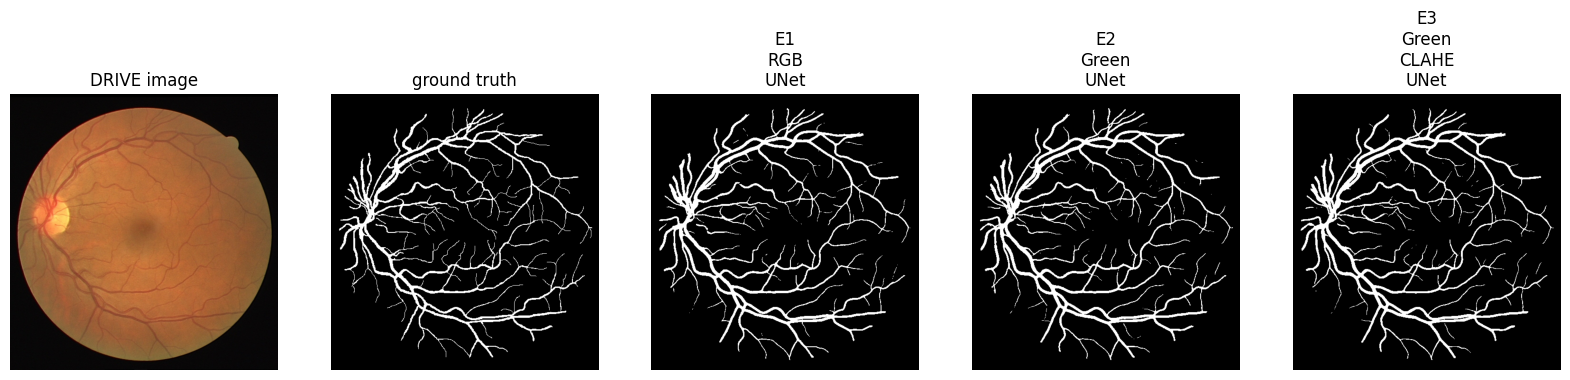

In [13]:
def show_predictions_for_experiments(rows, row_index=0, dataset_name='DRIVE'):
    image_path, label_path, fov_path = rows[row_index]
    image = load_rgb(image_path)
    label = load_mask(label_path)

    plt.figure(figsize=(4 * (len(EXPERIMENTS) + 2), 4))
    plt.subplot(1, len(EXPERIMENTS) + 2, 1)
    plt.imshow(image); plt.title(f'{dataset_name} image'); plt.axis('off')
    plt.subplot(1, len(EXPERIMENTS) + 2, 2)
    plt.imshow(label[..., 0], cmap='gray'); plt.title('ground truth'); plt.axis('off')

    for i, exp in enumerate(EXPERIMENTS):
        model = trained_models[exp['name']]
        prob = predict_full_image(model, image, exp['preprocess'], PATCH_SIZE, stride=64)
        plt.subplot(1, len(EXPERIMENTS) + 2, i + 3)
        plt.imshow(prob[..., 0] >= 0.5, cmap='gray')
        plt.title(exp['name'].replace('_', '\n'))
        plt.axis('off')
    plt.show()

show_predictions_for_experiments(test_rows, row_index=0, dataset_name='DRIVE')


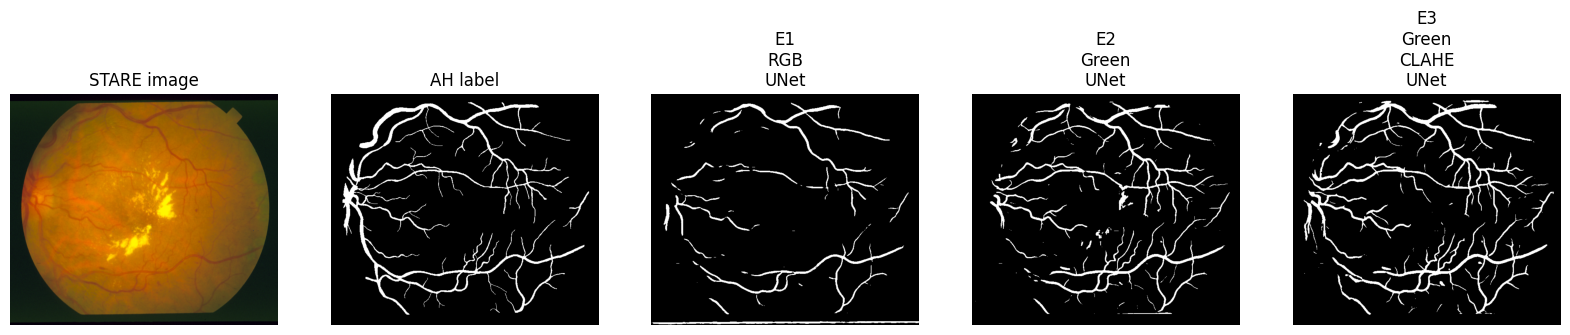

In [14]:
# STARE qualitative comparison using labels-ah as ground truth.
stare_images = sorted([p for p in (root / 'STARE/stare-images').glob('*.gz')])
stare_labels = {p.name.split('.')[0]: p for p in (root / 'STARE/labels-ah').glob('*.gz')}

img_path = stare_images[0]
key = img_path.name.split('.')[0]
image = load_rgb(img_path)
label = load_mask(stare_labels[key])

plt.figure(figsize=(4 * (len(EXPERIMENTS) + 2), 4))
plt.subplot(1, len(EXPERIMENTS) + 2, 1)
plt.imshow(image); plt.title('STARE image'); plt.axis('off')
plt.subplot(1, len(EXPERIMENTS) + 2, 2)
plt.imshow(label[..., 0], cmap='gray'); plt.title('AH label'); plt.axis('off')
for i, exp in enumerate(EXPERIMENTS):
    prob = predict_full_image(trained_models[exp['name']], image, exp['preprocess'], PATCH_SIZE, stride=64)
    plt.subplot(1, len(EXPERIMENTS) + 2, i + 3)
    plt.imshow(prob[..., 0] >= 0.5, cmap='gray')
    plt.title(exp['name'].replace('_', '\n'))
    plt.axis('off')
plt.show()


## Report Notes

Use the table from `summary` as your main quantitative result. Discuss whether green-channel extraction and CLAHE improve Dice on DRIVE, and whether the same trend transfers to STARE. If STARE is much worse, that supports the cross-dataset/domain-shift part of your project.


## 9. Threshold Optimization Without Retraining

The trained U-Net models output probability maps. Threshold optimization only changes how those probabilities are converted into binary vessel masks, so the saved `.keras` models can be reused directly.

This section first sweeps thresholds on DRIVE test images for analysis, then applies each experiment's best DRIVE threshold to both DRIVE and STARE. For a stricter final methodology, choose thresholds on a validation set and keep the DRIVE test set only for final reporting.


In [15]:
THRESHOLDS = [0.30, 0.40, 0.50, 0.60, 0.70]

# Reuse models from memory if available; otherwise load saved Keras files from the runtime.
def get_trained_model(exp):
    if 'trained_models' in globals() and exp['name'] in trained_models:
        return trained_models[exp['name']]

    model_path = f"best_{exp['name']}.keras"
    if not Path(model_path).exists():
        raise FileNotFoundError(
            f"Missing {model_path}. Run the training experiment first or upload/copy the saved model into this runtime."
        )

    return keras.models.load_model(
        model_path,
        custom_objects={
            'dice_coef': dice_coef,
            'dice_loss': dice_loss,
            'bce_dice_loss': bce_dice_loss,
        }
    )


def collect_drive_probabilities(model, preprocess_mode):
    cached = []
    for image_path, label_path, fov_path in test_rows:
        image = load_rgb(image_path)
        label = load_mask(label_path)
        fov = load_mask(fov_path)
        prob = predict_full_image(model, image, preprocess_mode, PATCH_SIZE, stride=64)
        cached.append({'image': image_path.name, 'label': label, 'fov': fov, 'prob': prob})
    return cached


def collect_stare_probabilities(model, preprocess_mode):
    stare_images = sorted([p for p in (root / 'STARE/stare-images').glob('*.gz')])
    stare_labels = {p.name.split('.')[0]: p for p in (root / 'STARE/labels-ah').glob('*.gz')}
    cached = []
    for img_path in stare_images:
        key = img_path.name.split('.')[0]
        image = load_rgb(img_path)
        label = load_mask(stare_labels[key])
        prob = predict_full_image(model, image, preprocess_mode, PATCH_SIZE, stride=64)
        cached.append({'image': img_path.name, 'label': label, 'fov': None, 'prob': prob})
    return cached


def evaluate_cached_predictions(cached_predictions, threshold):
    rows = [binary_metrics(item['label'], item['prob'], item['fov'], threshold=threshold)
            for item in cached_predictions]
    return {k: float(np.mean([r[k] for r in rows])) for k in rows[0]}


In [16]:
threshold_rows = []
drive_probability_cache = {}

for exp in EXPERIMENTS:
    print(f"Caching DRIVE probability maps for {exp['name']}...")
    model = get_trained_model(exp)
    drive_probability_cache[exp['name']] = collect_drive_probabilities(model, exp['preprocess'])

    for threshold in THRESHOLDS:
        metrics = evaluate_cached_predictions(drive_probability_cache[exp['name']], threshold)
        threshold_rows.append({
            'experiment': exp['name'],
            'threshold': round(float(threshold), 2),
            **metrics,
        })

threshold_df = pd.DataFrame(threshold_rows)
threshold_summary = threshold_df.copy()
for col in ['accuracy', 'dice', 'sensitivity', 'specificity']:
    threshold_summary[col] = threshold_summary[col].map(lambda x: round(x, 4))

threshold_summary.sort_values(['experiment', 'dice'], ascending=[True, False]).groupby('experiment').head(5)


Caching DRIVE probability maps for E1_RGB_UNet...
Caching DRIVE probability maps for E2_Green_UNet...
Caching DRIVE probability maps for E3_Green_CLAHE_UNet...


,experiment,threshold,accuracy,dice,sensitivity,specificity
1,E1_RGB_UNet,0.4,0.9543,0.8201,0.8242,0.9737
0,E1_RGB_UNet,0.3,0.9531,0.8194,0.8417,0.9697
2,E1_RGB_UNet,0.5,0.9549,0.8184,0.8055,0.9771
3,E1_RGB_UNet,0.6,0.9550,0.8150,0.7862,0.9800
4,E1_RGB_UNet,0.7,0.9547,0.8096,0.7647,0.9828
6,E2_Green_UNet,0.4,0.9542,0.8221,0.8363,0.9717
7,E2_Green_UNet,0.5,0.9553,0.8221,0.8176,0.9756
5,E2_Green_UNet,0.3,0.9525,0.8197,0.8539,0.9671
8,E2_Green_UNet,0.6,0.9557,0.8196,0.7977,0.9790
9,E2_Green_UNet,0.7,0.9556,0.8154,0.7758,0.9821


In [17]:
best_thresholds = (
    threshold_df
    .sort_values(['experiment', 'dice'], ascending=[True, False])
    .groupby('experiment', as_index=False)
    .head(1)
    .sort_values('experiment')
    .reset_index(drop=True)
)

best_thresholds_display = best_thresholds.copy()
for col in ['accuracy', 'dice', 'sensitivity', 'specificity']:
    best_thresholds_display[col] = best_thresholds_display[col].map(lambda x: round(x, 4))

best_thresholds_display


,experiment,threshold,accuracy,dice,sensitivity,specificity
0,E1_RGB_UNet,0.4,0.9543,0.8201,0.8242,0.9737
1,E2_Green_UNet,0.5,0.9553,0.8221,0.8176,0.9756
2,E3_Green_CLAHE_UNet,0.4,0.9543,0.8216,0.8320,0.9724


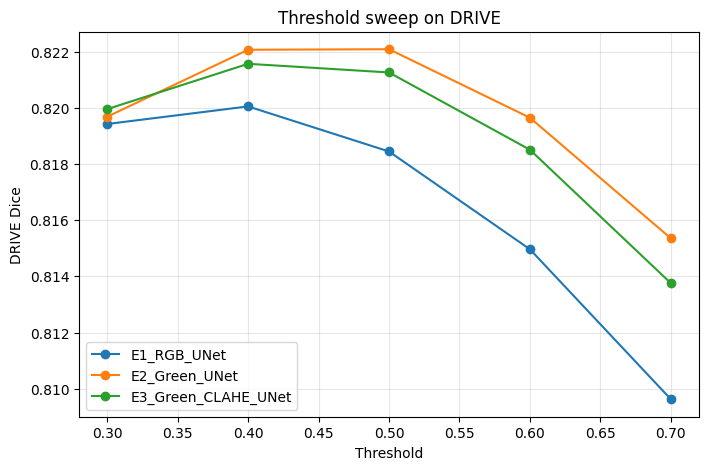

In [18]:
plt.figure(figsize=(8, 5))
for exp_name, group in threshold_df.groupby('experiment'):
    plt.plot(group['threshold'], group['dice'], marker='o', label=exp_name)
plt.xlabel('Threshold')
plt.ylabel('DRIVE Dice')
plt.title('Threshold sweep on DRIVE')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [19]:
optimized_rows = []
stare_probability_cache = {}

for _, row in best_thresholds.iterrows():
    exp = next(e for e in EXPERIMENTS if e['name'] == row['experiment'])
    best_t = float(row['threshold'])
    model = get_trained_model(exp)

    drive_metrics = evaluate_cached_predictions(drive_probability_cache[exp['name']], best_t)

    print(f"Caching STARE probability maps for {exp['name']}...")
    stare_probability_cache[exp['name']] = collect_stare_probabilities(model, exp['preprocess'])
    stare_metrics = evaluate_cached_predictions(stare_probability_cache[exp['name']], best_t)

    optimized_rows.append({
        'experiment': exp['name'],
        'dataset': 'DRIVE',
        'threshold': best_t,
        **drive_metrics,
    })
    optimized_rows.append({
        'experiment': exp['name'],
        'dataset': 'STARE',
        'threshold': best_t,
        **stare_metrics,
    })

optimized_results_df = pd.DataFrame(optimized_rows)
optimized_summary = optimized_results_df.copy()
for col in ['threshold', 'accuracy', 'dice', 'sensitivity', 'specificity']:
    optimized_summary[col] = optimized_summary[col].map(lambda x: round(x, 4))

optimized_summary


Caching STARE probability maps for E1_RGB_UNet...
Caching STARE probability maps for E2_Green_UNet...
Caching STARE probability maps for E3_Green_CLAHE_UNet...


,experiment,dataset,threshold,accuracy,dice,sensitivity,specificity
0,E1_RGB_UNet,DRIVE,0.4,0.9543,0.8201,0.8242,0.9737
1,E1_RGB_UNet,STARE,0.4,0.9617,0.7218,0.7335,0.9792
2,E2_Green_UNet,DRIVE,0.5,0.9553,0.8221,0.8176,0.9756
3,E2_Green_UNet,STARE,0.5,0.9653,0.7674,0.8014,0.9783
4,E3_Green_CLAHE_UNet,DRIVE,0.4,0.9543,0.8216,0.8320,0.9724
5,E3_Green_CLAHE_UNet,STARE,0.4,0.9584,0.7605,0.8803,0.9645


In [20]:
# Compare original threshold=0.5 results with optimized-threshold results if `results_df` exists.
if 'results_df' in globals():
    before = results_df.copy()
    before['threshold'] = 0.50
    before['setting'] = 'fixed_0.50'

    after = optimized_results_df.copy()
    after['setting'] = 'optimized_on_DRIVE'

    comparison = pd.concat([before, after], ignore_index=True)
    comparison = comparison[['setting', 'experiment', 'dataset', 'threshold', 'accuracy', 'dice', 'sensitivity', 'specificity']]
    comparison_display = comparison.copy()
    for col in ['threshold', 'accuracy', 'dice', 'sensitivity', 'specificity']:
        comparison_display[col] = comparison_display[col].map(lambda x: round(x, 4))
    display(comparison_display.sort_values(['experiment', 'dataset', 'setting']))
else:
    print('results_df not found. Showing optimized_summary only.')
    display(optimized_summary)


,setting,experiment,dataset,threshold,accuracy,dice,sensitivity,specificity
0,fixed_0.50,E1_RGB_UNet,DRIVE,0.5,0.9549,0.8184,0.8055,0.9771
6,optimized_on_DRIVE,E1_RGB_UNet,DRIVE,0.4,0.9543,0.8201,0.8242,0.9737
1,fixed_0.50,E1_RGB_UNet,STARE,0.5,0.9628,0.7181,0.7104,0.9822
7,optimized_on_DRIVE,E1_RGB_UNet,STARE,0.4,0.9617,0.7218,0.7335,0.9792
2,fixed_0.50,E2_Green_UNet,DRIVE,0.5,0.9553,0.8221,0.8176,0.9756
8,optimized_on_DRIVE,E2_Green_UNet,DRIVE,0.5,0.9553,0.8221,0.8176,0.9756
3,fixed_0.50,E2_Green_UNet,STARE,0.5,0.9653,0.7674,0.8014,0.9783
9,optimized_on_DRIVE,E2_Green_UNet,STARE,0.5,0.9653,0.7674,0.8014,0.9783
4,fixed_0.50,E3_Green_CLAHE_UNet,DRIVE,0.5,0.9552,0.8213,0.8131,0.9763
10,optimized_on_DRIVE,E3_Green_CLAHE_UNet,DRIVE,0.4,0.9543,0.8216,0.8320,0.9724


### How to Use These Results

For the report, use the threshold-sweep plot to show that the binary cutoff affects Dice. If optimized thresholds improve Dice meaningfully, report both the fixed `0.5` baseline and the optimized-threshold result, but state clearly that the threshold was selected using DRIVE evaluation images unless you later move threshold selection to a validation split.


## 10. Attention U-Net Experiment

This experiment keeps the best preprocessing from the earlier results, the green channel, and changes only the architecture from U-Net to Attention U-Net. The attention gates help the decoder focus on relevant encoder features before skip-connection fusion.


In [21]:
ATTENTION_EXPERIMENT = {
    'name': 'E4_Green_Attention_UNet',
    'preprocess': 'green',
    'input_channels': 1,
}


In [22]:
def attention_gate(skip, gating, inter_filters):
    theta_x = layers.Conv2D(inter_filters, 1, padding='same')(skip)
    phi_g = layers.Conv2D(inter_filters, 1, padding='same')(gating)

    add = layers.Add()([theta_x, phi_g])
    act = layers.Activation('relu')(add)
    psi = layers.Conv2D(1, 1, padding='same')(act)
    psi = layers.Activation('sigmoid')(psi)

    return layers.Multiply()([skip, psi])


def decoder_attention_block(x, skip, filters):
    x = layers.UpSampling2D()(x)
    gated_skip = attention_gate(skip, x, max(filters // 2, 1))
    x = layers.Concatenate()([x, gated_skip])
    return conv_block(x, filters)


def build_attention_unet(input_shape=(128, 128, 1), base=32):
    inputs = keras.Input(input_shape)

    c1 = conv_block(inputs, base)
    p1 = layers.MaxPool2D()(c1)

    c2 = conv_block(p1, base * 2)
    p2 = layers.MaxPool2D()(c2)

    c3 = conv_block(p2, base * 4)
    p3 = layers.MaxPool2D()(c3)

    bottleneck = conv_block(p3, base * 8)

    d3 = decoder_attention_block(bottleneck, c3, base * 4)
    d2 = decoder_attention_block(d3, c2, base * 2)
    d1 = decoder_attention_block(d2, c1, base)

    outputs = layers.Conv2D(1, 1, activation='sigmoid')(d1)
    return keras.Model(inputs, outputs, name='Attention_UNet')


attention_model = build_attention_unet((PATCH_SIZE, PATCH_SIZE, ATTENTION_EXPERIMENT['input_channels']), base=32)
attention_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef],
)
attention_model.summary()


Model: "Attention_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_15 (Conv2D)  │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_15[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 128, 128,  │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_17[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_18 (Conv2D)  │ (None, 64, 64,    │     36,928 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        256 │ conv2d_18[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_19 (Conv2D)  │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_19[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_20 (Conv2D)  │ (None, 32, 32,    │    147,584 │ batch_normalizat… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 32,    │        512 │ conv2d_20[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ batch_normalizat… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_21 (Conv2D)  │ (None, 16, 16,    │    295,168 │ max_pooling2d_5[

 Total params: 1,984,532 (7.57 MB)

 Trainable params: 1,981,716 (7.56 MB)

 Non-trainable params: 2,816 (11.00 KB)

In [23]:
tf.keras.backend.clear_session()
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

X_att, Y_att = extract_patches(
    train_rows,
    ATTENTION_EXPERIMENT['preprocess'],
    PATCH_SIZE,
    PATCHES_PER_IMAGE,
)
print('patches:', X_att.shape, Y_att.shape, 'positive pixel ratio:', float(Y_att.mean()))

train_ds_att, val_ds_att = make_datasets(X_att, Y_att, BATCH_SIZE)

attention_model = build_attention_unet((PATCH_SIZE, PATCH_SIZE, ATTENTION_EXPERIMENT['input_channels']), base=32)
attention_model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=bce_dice_loss,
    metrics=['accuracy', dice_coef],
)

attention_ckpt_path = f"best_{ATTENTION_EXPERIMENT['name']}.keras"
attention_callbacks = [
    keras.callbacks.ModelCheckpoint(attention_ckpt_path, monitor='val_dice_coef', mode='max', save_best_only=True),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
]

attention_history = attention_model.fit(
    train_ds_att,
    validation_data=val_ds_att,
    epochs=EPOCHS,
    callbacks=attention_callbacks,
)

attention_model = keras.models.load_model(
    attention_ckpt_path,
    custom_objects={
        'dice_coef': dice_coef,
        'dice_loss': dice_loss,
        'bce_dice_loss': bce_dice_loss,
    },
)

if 'trained_models' not in globals():
    trained_models = {}
trained_models[ATTENTION_EXPERIMENT['name']] = attention_model


patches: (5000, 128, 128, 1) (5000, 128, 128, 1) positive pixel ratio: 0.11718077212572098
Epoch 1/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 40s 70ms/step - accuracy: 0.9251 - dice_coef: 0.7367 - loss: 0.6727 - val_accuracy: 0.8836 - val_dice_coef: 8.8149e-04 - val_loss: 1.7114 - learning_rate: 0.0010
Epoch 2/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9537 - dice_coef: 0.7993 - loss: 0.3816 - val_accuracy: 0.9312 - val_dice_coef: 0.5875 - val_loss: 0.7039 - learning_rate: 0.0010
Epoch 3/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9555 - dice_coef: 0.8071 - loss: 0.3551 - val_accuracy: 0.9562 - val_dice_coef: 0.7907 - val_loss: 0.3709 - learning_rate: 0.0010
Epoch 4/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - accuracy: 0.9569 - dice_coef: 0.8129 - loss: 0.3416 - val_accuracy: 0.9580 - val_dice_coef: 0.8142 - val_loss: 0.3386 - learning_rate: 0.0010
Epoch 5/20
266/266 ━━━━━━━━━━━━━━━━━━━━ 5s 18ms/step - accuracy: 0.9572 - dice_coef: 0.8147 - loss: 0.3375 - val_acc

In [24]:
attention_drive_metrics = evaluate_drive(attention_model, ATTENTION_EXPERIMENT['preprocess'])
attention_stare_metrics = evaluate_stare(attention_model, ATTENTION_EXPERIMENT['preprocess'])

attention_results_df = pd.DataFrame([
    {'experiment': ATTENTION_EXPERIMENT['name'], 'dataset': 'DRIVE', **attention_drive_metrics},
    {'experiment': ATTENTION_EXPERIMENT['name'], 'dataset': 'STARE', **attention_stare_metrics},
])

attention_summary = attention_results_df.copy()
for col in ['accuracy', 'dice', 'sensitivity', 'specificity']:
    attention_summary[col] = attention_summary[col].map(lambda x: round(x, 4))

attention_summary


,experiment,dataset,accuracy,dice,sensitivity,specificity
0,E4_Green_Attention_UNet,DRIVE,0.9554,0.8168,0.7876,0.9800
1,E4_Green_Attention_UNet,STARE,0.9647,0.7765,0.8367,0.9748


In [25]:
# Compare Attention U-Net against the previous three experiments if `results_df` exists.
if 'results_df' in globals():
    architecture_comparison = pd.concat([results_df, attention_results_df], ignore_index=True)
else:
    architecture_comparison = attention_results_df.copy()

architecture_summary = architecture_comparison.copy()
for col in ['accuracy', 'dice', 'sensitivity', 'specificity']:
    architecture_summary[col] = architecture_summary[col].map(lambda x: round(x, 4))

architecture_summary.sort_values(['dataset', 'dice'], ascending=[True, False])


,experiment,dataset,accuracy,dice,sensitivity,specificity
2,E2_Green_UNet,DRIVE,0.9553,0.8221,0.8176,0.9756
4,E3_Green_CLAHE_UNet,DRIVE,0.9552,0.8213,0.8131,0.9763
0,E1_RGB_UNet,DRIVE,0.9549,0.8184,0.8055,0.9771
6,E4_Green_Attention_UNet,DRIVE,0.9554,0.8168,0.7876,0.9800
7,E4_Green_Attention_UNet,STARE,0.9647,0.7765,0.8367,0.9748
5,E3_Green_CLAHE_UNet,STARE,0.9619,0.7726,0.8657,0.9695
3,E2_Green_UNet,STARE,0.9653,0.7674,0.8014,0.9783
1,E1_RGB_UNet,STARE,0.9628,0.7181,0.7104,0.9822


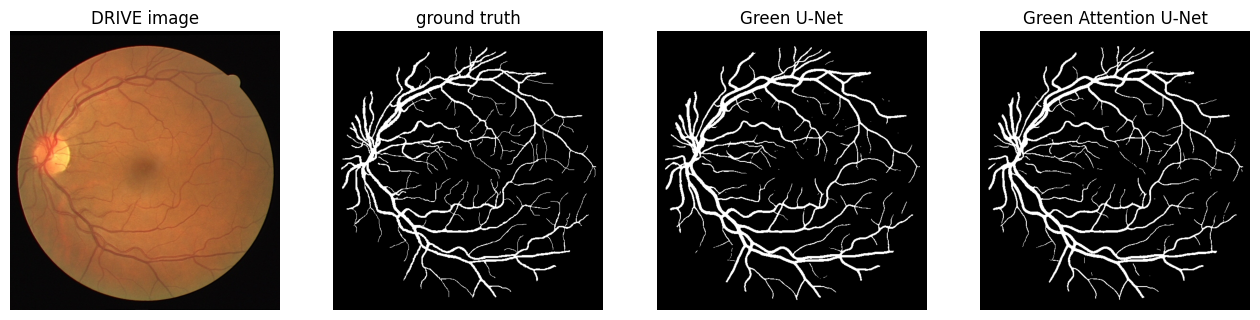

In [26]:
# Qualitative comparison: best previous model, Green U-Net, versus Green Attention U-Net.
image_path, label_path, fov_path = test_rows[0]
image = load_rgb(image_path)
label = load_mask(label_path)

models_to_show = []
if 'trained_models' in globals() and 'E2_Green_UNet' in trained_models:
    models_to_show.append(('Green U-Net', trained_models['E2_Green_UNet'], 'green'))
models_to_show.append(('Green Attention U-Net', attention_model, 'green'))

plt.figure(figsize=(4 * (len(models_to_show) + 2), 4))
plt.subplot(1, len(models_to_show) + 2, 1)
plt.imshow(image); plt.title('DRIVE image'); plt.axis('off')
plt.subplot(1, len(models_to_show) + 2, 2)
plt.imshow(label[..., 0], cmap='gray'); plt.title('ground truth'); plt.axis('off')

for i, (title, model, mode) in enumerate(models_to_show):
    prob = predict_full_image(model, image, mode, PATCH_SIZE, stride=64)
    plt.subplot(1, len(models_to_show) + 2, i + 3)
    plt.imshow(prob[..., 0] >= 0.5, cmap='gray')
    plt.title(title)
    plt.axis('off')
plt.show()


### Attention U-Net Notes

When interpreting this experiment, compare `E4_Green_Attention_UNet` mainly against `E2_Green_UNet`, because both use the same green-channel input. If Attention U-Net improves DRIVE but hurts STARE, it may be fitting DRIVE-specific details. If it improves both, it is a strong candidate for your final model.
